# Task 2: Naïve Bayes and Support Vector Machine

Develop classification models using Gaussian Naïve Bayes and Linear Kernel Support Vector Machine (SVM) using the Sonar dataset.

In [1]:
import pandas as pd

In [2]:
from sklearn.model_selection import train_test_split

In [3]:
from sklearn.preprocessing import StandardScaler

In [4]:
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"

In [5]:
sonar_features = [f"F_{i}" for i in range(1, 61)]

In [6]:
sonar_columns = sonar_features + ["Class"]

In [7]:
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)

Sonar Dataset Shape: (208, 61)

First Five Rows:
   Feature_1  Feature_2  Feature_3  Feature_4  Feature_5  Feature_6  \
0     0.0200     0.0371     0.0428     0.0207     0.0954     0.0986   
1     0.0453     0.0523     0.0843     0.0689     0.1183     0.2583   
2     0.0262     0.0582     0.1099     0.1083     0.0974     0.2280   
3     0.0100     0.0171     0.0623     0.0205     0.0205     0.0368   
4     0.0762     0.0666     0.0481     0.0394     0.0590     0.0649   

   Feature_7  Feature_8  Feature_9  Feature_10  ...  Feature_52  Feature_53  \
0     0.1539     0.1601     0.3109      0.2111  ...      0.0027      0.0065   
1     0.2156     0.3481     0.3337      0.2872  ...      0.0084      0.0089   
2     0.2431     0.3771     0.5598      0.6194  ...      0.0232      0.0166   
3     0.1098     0.1276     0.0598      0.1264  ...      0.0121      0.0036   
4     0.1209     0.2467     0.3564      0.4459  ...      0.0031      0.0054   

   Feature_54  Feature_55  Feature_56  Feature_57

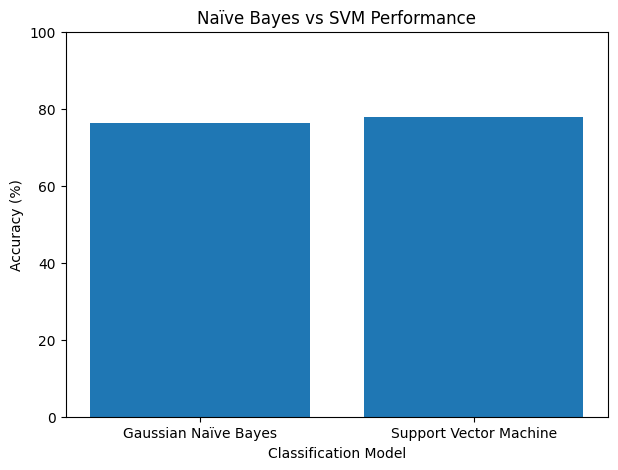


----------------------------------------
Conclusion
----------------------------------------
Support Vector Machine achieved higher classification accuracy than Gaussian Naïve Bayes.
The Sonar dataset was successfully classified using Gaussian Naïve Bayes and Support Vector Machine.


In [8]:
# Experiment 03 - Task 02
# Naïve Bayes and Support Vector Machine Classification
# Dataset: Sonar Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# ---------------------------------------------------------
# 1. Load Sonar Dataset
# ---------------------------------------------------------

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"

sonar_columns = [f"Feature_{i}" for i in range(1, 61)] + ["Target"]

sonar_df = pd.read_csv(
    url,
    header=None,
    names=sonar_columns
)

print("Sonar Dataset Shape:", sonar_df.shape)

print("\nFirst Five Rows:")
print(sonar_df.head())

# ---------------------------------------------------------
# 2. Separate Features and Target
# ---------------------------------------------------------

X = sonar_df.iloc[:, :-1]

y = sonar_df.iloc[:, -1]

# ---------------------------------------------------------
# 3. Convert Target Labels
# R = Rock -> 0
# M = Mine -> 1
# ---------------------------------------------------------

y = y.map({
    "R": 0,
    "M": 1
})

print("\nTarget Distribution:")
print(y.value_counts())

# ---------------------------------------------------------
# 4. Split Dataset
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

print("\nTraining Set Shape:", X_train.shape)

print("Testing Set Shape:", X_test.shape)

# ---------------------------------------------------------
# 5. Standardize Features
# ---------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------------------
# 6. Gaussian Naïve Bayes
# ---------------------------------------------------------

nb_model = GaussianNB()

nb_model.fit(
    X_train_scaled,
    y_train
)

# ---------------------------------------------------------
# 7. Naïve Bayes Predictions
# ---------------------------------------------------------

nb_predictions = nb_model.predict(
    X_test_scaled
)

# ---------------------------------------------------------
# 8. Naïve Bayes Accuracy
# ---------------------------------------------------------

nb_accuracy = accuracy_score(
    y_test,
    nb_predictions
)

print("\n----------------------------------------")
print("Gaussian Naïve Bayes")
print("----------------------------------------")

print(
    f"Accuracy: {nb_accuracy * 100:.2f}%"
)

# ---------------------------------------------------------
# 9. Naïve Bayes Confusion Matrix
# ---------------------------------------------------------

nb_cm = confusion_matrix(
    y_test,
    nb_predictions
)

print("\nNaïve Bayes Confusion Matrix:")
print(nb_cm)

# ---------------------------------------------------------
# 10. Naïve Bayes Classification Report
# ---------------------------------------------------------

print("\nNaïve Bayes Classification Report:")

print(
    classification_report(
        y_test,
        nb_predictions,
        target_names=["Rock", "Mine"]
    )
)

# ---------------------------------------------------------
# 11. Support Vector Machine
# ---------------------------------------------------------

svm_model = SVC(
    kernel="linear",
    probability=True,
    random_state=42
)

svm_model.fit(
    X_train_scaled,
    y_train
)

# ---------------------------------------------------------
# 12. SVM Predictions
# ---------------------------------------------------------

svm_predictions = svm_model.predict(
    X_test_scaled
)

# ---------------------------------------------------------
# 13. SVM Accuracy
# ---------------------------------------------------------

svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

print("\n----------------------------------------")
print("Support Vector Machine")
print("----------------------------------------")

print(
    f"Accuracy: {svm_accuracy * 100:.2f}%"
)

# ---------------------------------------------------------
# 14. SVM Confusion Matrix
# ---------------------------------------------------------

svm_cm = confusion_matrix(
    y_test,
    svm_predictions
)

print("\nSVM Confusion Matrix:")
print(svm_cm)

# ---------------------------------------------------------
# 15. SVM Classification Report
# ---------------------------------------------------------

print("\nSVM Classification Report:")

print(
    classification_report(
        y_test,
        svm_predictions,
        target_names=["Rock", "Mine"]
    )
)

# ---------------------------------------------------------
# 16. Model Comparison
# ---------------------------------------------------------

comparison = pd.DataFrame({
    "Model": [
        "Gaussian Naïve Bayes",
        "Support Vector Machine"
    ],
    "Accuracy (%)": [
        nb_accuracy * 100,
        svm_accuracy * 100
    ]
})

print("\n----------------------------------------")
print("Model Performance Comparison")
print("----------------------------------------")

print(
    comparison.to_string(index=False)
)

# ---------------------------------------------------------
# 17. Accuracy Comparison Graph
# ---------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy (%)"]
)

plt.xlabel("Classification Model")

plt.ylabel("Accuracy (%)")

plt.title("Naïve Bayes vs SVM Performance")

plt.ylim(0, 100)

plt.show()

# ---------------------------------------------------------
# 18. Conclusion
# ---------------------------------------------------------

print("\n----------------------------------------")
print("Conclusion")
print("----------------------------------------")

if nb_accuracy > svm_accuracy:
    print(
        "Gaussian Naïve Bayes achieved higher "
        "classification accuracy than SVM."
    )

elif svm_accuracy > nb_accuracy:
    print(
        "Support Vector Machine achieved higher "
        "classification accuracy than Gaussian Naïve Bayes."
    )

else:
    print(
        "Both models achieved the same classification accuracy."
    )

print(
    "The Sonar dataset was successfully classified "
    "using Gaussian Naïve Bayes and Support Vector Machine."
)